In [1]:
# ANN - MNIST Image Classification

# Problem Statement:
# Build and train an Artificial Neural Network (ANN) to classify handwritten digits from the MNIST dataset.
# https://corochann.com/wp-content/uploads/2021/09/mnist_plot.png

# Import necessary libraries
import tensorflow as tf
print("TensorFlow version:", tf.__version__)

# What is TensorFlow?
# TensorFlow is an open-source machine learning framework developed by Google. It is widely used for
# building and deploying machine learning models, particularly deep learning models. TensorFlow provides
# a flexible ecosystem of tools, libraries, and community resources that allows researchers and developers
# to create machine learning applications efficiently.

TensorFlow version: 2.19.0


In [ ]:
# TensorFlow 2.0 (Eager execution by default, more intuitive and user-friendly, improved performance)

#                 |

# Keras (High-level API for building and training deep learning models, user-friendly, easy to learn)

#                 |

# TF 1.0 (Difficult to learn, not user-friendly, low-level API)

In [2]:
# https://www.researchgate.net/profile/Benoit-Dupont-2/publication/337402608/figure/fig4/AS:827372358086659@1574272350931/Pixel-Data-Diagram-of-Abraham-Lincoln-166.png

# https://miro.medium.com/v2/1*THbDE9VGnlsm2lxnKZug2g.png

---

### 📝 Problem Statement: Handwritten Digit Recognition Using Deep Learning on MNIST Dataset

#### **Objective:**
To develop and evaluate a deep learning model that can accurately classify handwritten digits (0–9) from grayscale images using the MNIST dataset. The goal is to achieve high accuracy and generalization ability on unseen digit images.

#### **Background:**
Handwritten digit recognition is a foundational task in the field of computer vision and machine learning. The MNIST dataset is a benchmark dataset consisting of 70,000 28x28 pixel grayscale images of handwritten digits — 60,000 for training and 10,000 for testing. Each image is labeled with the correct digit (0 to 9).

Deep learning, especially Convolutional Neural Networks (CNNs), has proven to be highly effective in image classification tasks. By applying deep learning techniques to the MNIST dataset, we aim to learn a robust model capable of recognizing handwritten digits with minimal pre-processing.

#### **Dataset Description:**
- **Name:** MNIST (Modified National Institute of Standards and Technology) Dataset  
- **Format:** 28x28 grayscale images  
- **Training Samples:** 60,000  
- **Test Samples:** 10,000  
- **Classes:** 10 (Digits 0 through 9)

#### **Tasks:**
1. Load and preprocess the MNIST dataset.
2. Design and implement a neural network (fully connected or CNN).
3. Train the model on the training data.
4. Evaluate the model on the test data.
5. Tune hyperparameters (learning rate, number of layers, dropout, etc.) to improve performance.
6. Visualize model performance using accuracy/loss plots and confusion matrix.
7. (Optional) Test the model on custom handwritten digits.

#### **Success Criteria:**
- Achieve at least 98% accuracy on the MNIST test set.
- Demonstrate generalization with minimal overfitting.
- Clear visualization of results and performance metrics.

#### **Tools and Libraries:**
- Python
- TensorFlow or PyTorch
- NumPy, Matplotlib, and Seaborn for visualization

---







In [3]:
# Load the MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Print the shape of the data
print("Training data shape:", x_train.shape, y_train.shape)
print("Testing data shape:", x_test.shape, y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28) (60000,)
Testing data shape: (10000, 28, 28) (10000,)


In [4]:
# Lets look at the shape of the first image in the training set
x_train[0].shape

(28, 28)

In [5]:
# x_train # 0 to 59999
# x_train[0]  # First image in training set
# y_train[0]  # Label for the first image

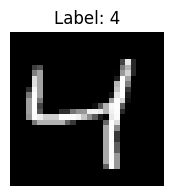

In [8]:
# Plot the image - 0th image in training set along with its label in the title
import matplotlib.pyplot as plt

plt.figure(figsize=(2,2))
plt.imshow(x_train[2], cmap='gray') # imshow() is used to display an image, cmap='gray' is used to display the image in grayscale
plt.title("Label: {}".format(y_train[2]))
plt.axis('off')
plt.show()

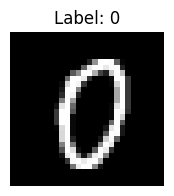

In [9]:
# Plot the image - 1000th image in training set along with its label in the title

plt.figure(figsize=(2,2))
plt.imshow(x_train[1000], cmap='gray')
plt.title(f"Label: {y_train[1000]}")
plt.axis('off')
plt.show()

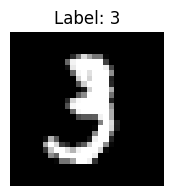

In [10]:
# Plot the image - 10th image in training set along with its label in the title

plt.figure(figsize=(2,2))
plt.imshow(x_train[10], cmap='gray')
plt.title(f"Label: {y_train[10]}")
plt.axis('off')
plt.show()

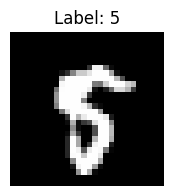

In [11]:
# Plot the image - 5598th image in training set along with its label in the title

plt.figure(figsize=(2,2))
plt.imshow(x_train[5598], cmap='gray')
plt.title(f"Label: {y_train[5598]}")
plt.axis('off')
plt.show()

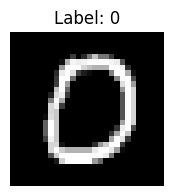

In [12]:
# Plot the image - 10th image in testing set along with its label in the title

plt.figure(figsize=(2,2))
plt.imshow(x_test[10], cmap='gray')
plt.title(f"Label: {y_test[10]}")
plt.axis('off')
plt.show()

In [13]:
# All image pixels are in the range of 0 to 255.

# These big numbers can make it difficult for the model to learn effectively. To address this, we will normalize the pixel values to a range of 0 to 1 by dividing each pixel value by 255. This process is called normalization and helps improve the performance of the model.

#  0/255 = 0
# 255/255 = 1

# Normalize the data
x_train = x_train / 255.0
x_test = x_test / 255.0

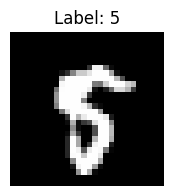

In [14]:
# Plot the image - 5598th image in training set along with its label in the title

plt.figure(figsize=(2,2))
plt.imshow(x_train[5598], cmap='gray')
plt.title(f"Label: {y_train[5598]}")
plt.axis('off')
plt.show()

![image.png](attachment:image.png)

In [15]:
# Creating the ANN model
# Build or Instantiate the model - Creating the body frame of the car

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras import Input

model = Sequential()
model.add(Input(shape=(28, 28)))  # Input layer
model.add(Flatten())  # Flattening the 2D image to 1D vector
model.add(Dense(128, activation='relu'))  # First hidden layer with 128 neurons
model.add(Dense(256, activation='relu'))  # Second hidden layer with 256 neurons
model.add(Dense(10, activation='softmax'))  # Output layer with 10 neurons

# Input Layer: Accepts 28x28 pixel images. ==> Input Layer
# Hidden Layers ==> Dense Layers
# Output Layer ==> Dense Layer

# Activation Functions:
# 1. Input Layer: No activation function is applied here as it simply passes the input data to the next layer.
# 2. Hidden Layers: relu, leaky relu, elu, silu, gelu, selu, etc.
# 3. Output Layer:
# a. Binary Classification: sigmoid
# b. Multi-class Classification: softmax
# c. Regression: linear

In [16]:
# Compile the model - Fit the engine to the body frame - Optimize the engine and reduce the fuel loss

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [17]:
# Print the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,074 (531.54 KB)

 Trainable params: 136,074 (531.54 KB)

 Non-trainable params: 0 (0.00 B)

In [18]:
r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=10)  # Training the model for 10 epochs

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8846 - loss: 0.3890 - val_accuracy: 0.9630 - val_loss: 0.1129
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9699 - loss: 0.0972 - val_accuracy: 0.9741 - val_loss: 0.0843
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9796 - loss: 0.0629 - val_accuracy: 0.9751 - val_loss: 0.0765
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9863 - loss: 0.0435 - val_accuracy: 0.9774 - val_loss: 0.0773
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9892 - loss: 0.0352 - val_accuracy: 0.9760 - val_loss: 0.0831
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9906 - loss: 0.0295 - val_accuracy: 0.9773 - val_loss: 0.0875
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9925 - loss: 0.0238 - val_accuracy: 0.9800 - val_loss: 0.0817
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9932 - loss: 0.0210 

In [19]:
# Print the "r" history keys
print(r.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


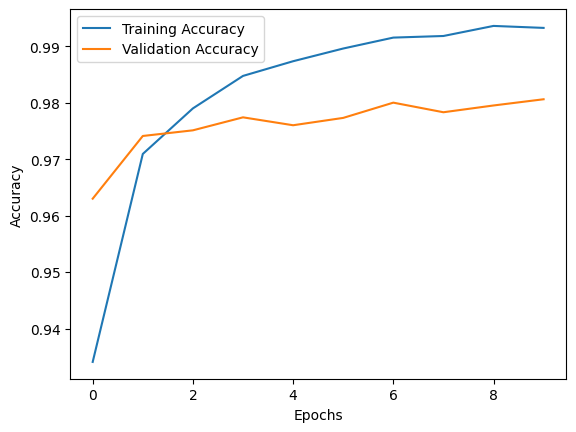

In [20]:
# Plot the accuracy and validation accuracy per epoch
plt.plot(r.history['accuracy'], label='Training Accuracy')
plt.plot(r.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

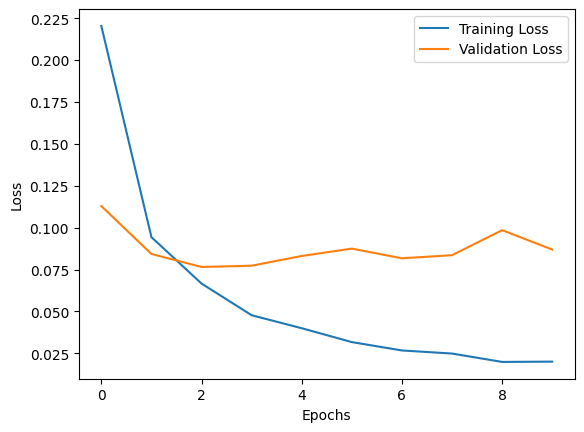

In [21]:
# Plot the loss and validation loss per epoch
plt.plot(r.history['loss'], label='Training Loss')
plt.plot(r.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [22]:
# Evalating the model on test data
model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9783 - loss: 0.1043


[0.08692184835672379, 0.9805999994277954]

In [23]:
x_test.shape

(10000, 28, 28)

In [24]:
model.predict(x_test).shape

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


(10000, 10)

In [25]:
import numpy as np
y_pred = model.predict(x_test).argmax(axis=1)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([7, 2, 1, ..., 4, 5, 6])

In [ ]:
y_pred.shape

(10000,)

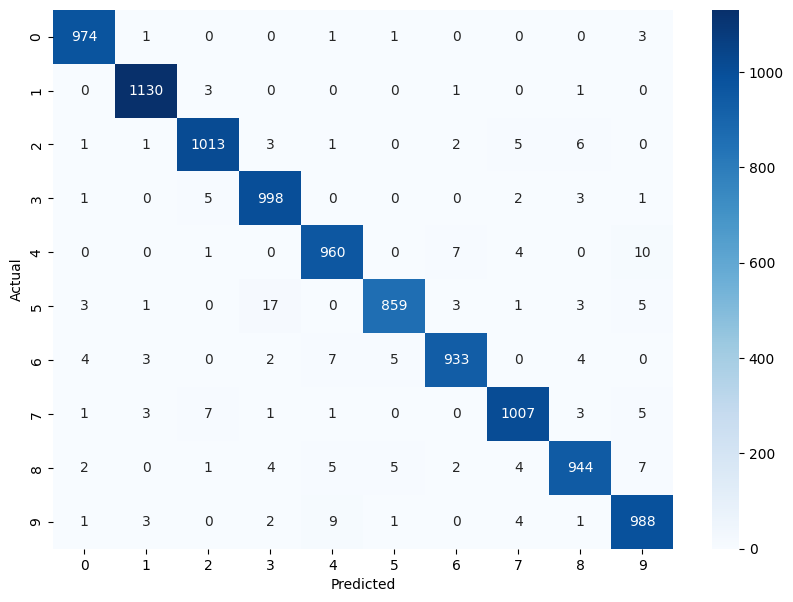

In [26]:
# Print the confusion matrix using seaborn heatmap
import seaborn as sns # for data visualization
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [27]:
np.where(y_test != y_pred) # Indices where predictions are incorrect

(array([ 115,  247,  321,  340,  358,  445,  447,  508,  582,  610,  619,
         684,  720,  877,  924,  947,  951,  956,  965, 1014, 1044, 1112,
        1156, 1226, 1232, 1247, 1260, 1299, 1319, 1393, 1395, 1465, 1494,
        1522, 1530, 1549, 1554, 1609, 1681, 1717, 1782, 1790, 1828, 1901,
        1941, 2024, 2035, 2053, 2070, 2098, 2109, 2118, 2125, 2130, 2135,
        2182, 2224, 2369, 2387, 2422, 2488, 2597, 2654, 2720, 2771, 2810,
        2863, 2877, 2896, 2927, 2939, 2995, 3060, 3073, 3102, 3117, 3130,
        3172, 3284, 3289, 3405, 3422, 3474, 3475, 3503, 3520, 3558, 3559,
        3727, 3767, 3776, 3780, 3808, 3818, 3853, 3871, 3893, 3941, 3985,
        4027, 4065, 4075, 4102, 4156, 4163, 4176, 4224, 4271, 4289, 4300,
        4355, 4360, 4403, 4419, 4433, 4439, 4443, 4500, 4504, 4534, 4571,
        4601, 4639, 4671, 4699, 4723, 4731, 4807, 4814, 4823, 4860, 4918,
        4956, 4997, 5199, 5634, 5676, 5745, 5749, 5821, 5842, 5887, 5936,
        5937, 5955, 5972, 5973, 5981, 

In [28]:
# Find the indices where predictions are incorrect
misclassified_indices = np.where(y_test != y_pred)[0]
misclassified_indices

array([ 115,  247,  321,  340,  358,  445,  447,  508,  582,  610,  619,
        684,  720,  877,  924,  947,  951,  956,  965, 1014, 1044, 1112,
       1156, 1226, 1232, 1247, 1260, 1299, 1319, 1393, 1395, 1465, 1494,
       1522, 1530, 1549, 1554, 1609, 1681, 1717, 1782, 1790, 1828, 1901,
       1941, 2024, 2035, 2053, 2070, 2098, 2109, 2118, 2125, 2130, 2135,
       2182, 2224, 2369, 2387, 2422, 2488, 2597, 2654, 2720, 2771, 2810,
       2863, 2877, 2896, 2927, 2939, 2995, 3060, 3073, 3102, 3117, 3130,
       3172, 3284, 3289, 3405, 3422, 3474, 3475, 3503, 3520, 3558, 3559,
       3727, 3767, 3776, 3780, 3808, 3818, 3853, 3871, 3893, 3941, 3985,
       4027, 4065, 4075, 4102, 4156, 4163, 4176, 4224, 4271, 4289, 4300,
       4355, 4360, 4403, 4419, 4433, 4439, 4443, 4500, 4504, 4534, 4571,
       4601, 4639, 4671, 4699, 4723, 4731, 4807, 4814, 4823, 4860, 4918,
       4956, 4997, 5199, 5634, 5676, 5745, 5749, 5821, 5842, 5887, 5936,
       5937, 5955, 5972, 5973, 5981, 5997, 6011, 60

In [29]:
# Print the total number of misclassified images
print(f'Total misclassified images: {len(misclassified_indices)}')

Total misclassified images: 194


In [39]:
(194 / 10000) * 100 # Percentage of misclassified images

1.94

In [40]:
100 - 1.94 # Percentage of correctly classified images

98.06

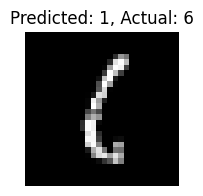

In [41]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)

plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

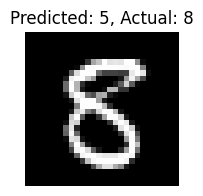

In [42]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

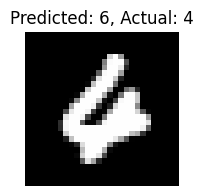

In [43]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

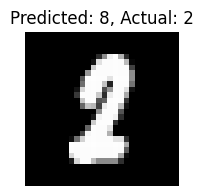

In [44]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

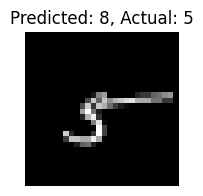

In [45]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

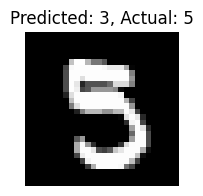

In [46]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

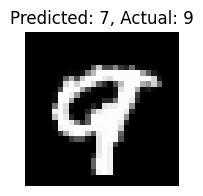

In [47]:
# Lets randomly see some of the missclassified images along with their predicted and actual labels

i = np.random.choice(misclassified_indices)
plt.figure(figsize=(2,2))
plt.imshow(x_test[i], cmap='gray')
plt.title(f'Predicted: {y_pred[i]}, Actual: {y_test[i]}')
plt.axis('off')
plt.show()

# Happy Learning